In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from tqdm import tqdm
from scipy.signal import savgol_filter
from scipy.fft import fft

from rfml_uav.drone_rf.consts import BUI, M, FS, BUI_dict
from rfml_uav.drone_rf.utils import get_segment_count

load_dotenv()

True

In [ ]:
# Path of raw RF data
filename = os.path.join(os.getenv("DATA_PATH"), "raw")
save_path = os.path.join(os.getenv("DATA_PATH"), "FFT") 

if not os.path.exists(save_path):
    os.mkdir(save_path)

f = 2400 + np.arange(0, FS, FS/M)  # Frequency array for plotting

S = 15  # Number of points in the moving average filter for smoothing

In [ ]:

for bui in BUI:
    x = np.empty(0)
    y = np.empty(0)
    for n in tqdm(range(get_segment_count(bui))):
        x = np.append(x, np.loadtxt(os.path.join(filename, f"{bui}L_{n}.csv"), delimiter=','))
        y = np.append(y, np.loadtxt(os.path.join(filename, f"{bui}H_{n}.csv"), delimiter=',')) 

    # Low band
    xf = fft(x, M // 2)
    x_mag = np.abs(xf)[:len(x)//2]

    # High band
    yf = fft(y, M // 2)
    y_mag = np.abs(yf)[:len(y)//2]

    np.savetxt(os.path.join(save_path, f'{bui}.csv'), np.hstack((x_mag, y_mag)), delimiter=',')

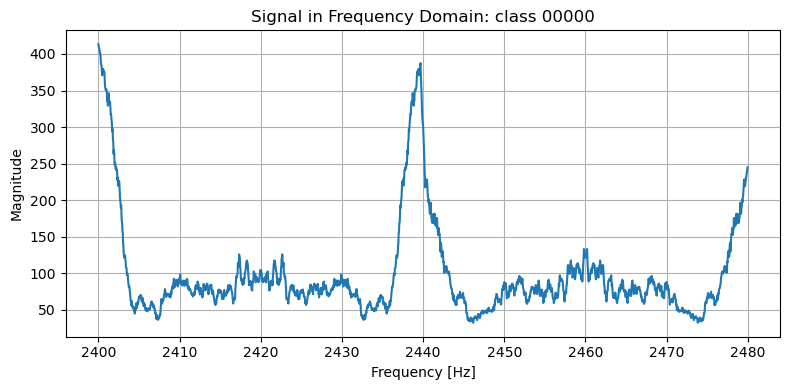

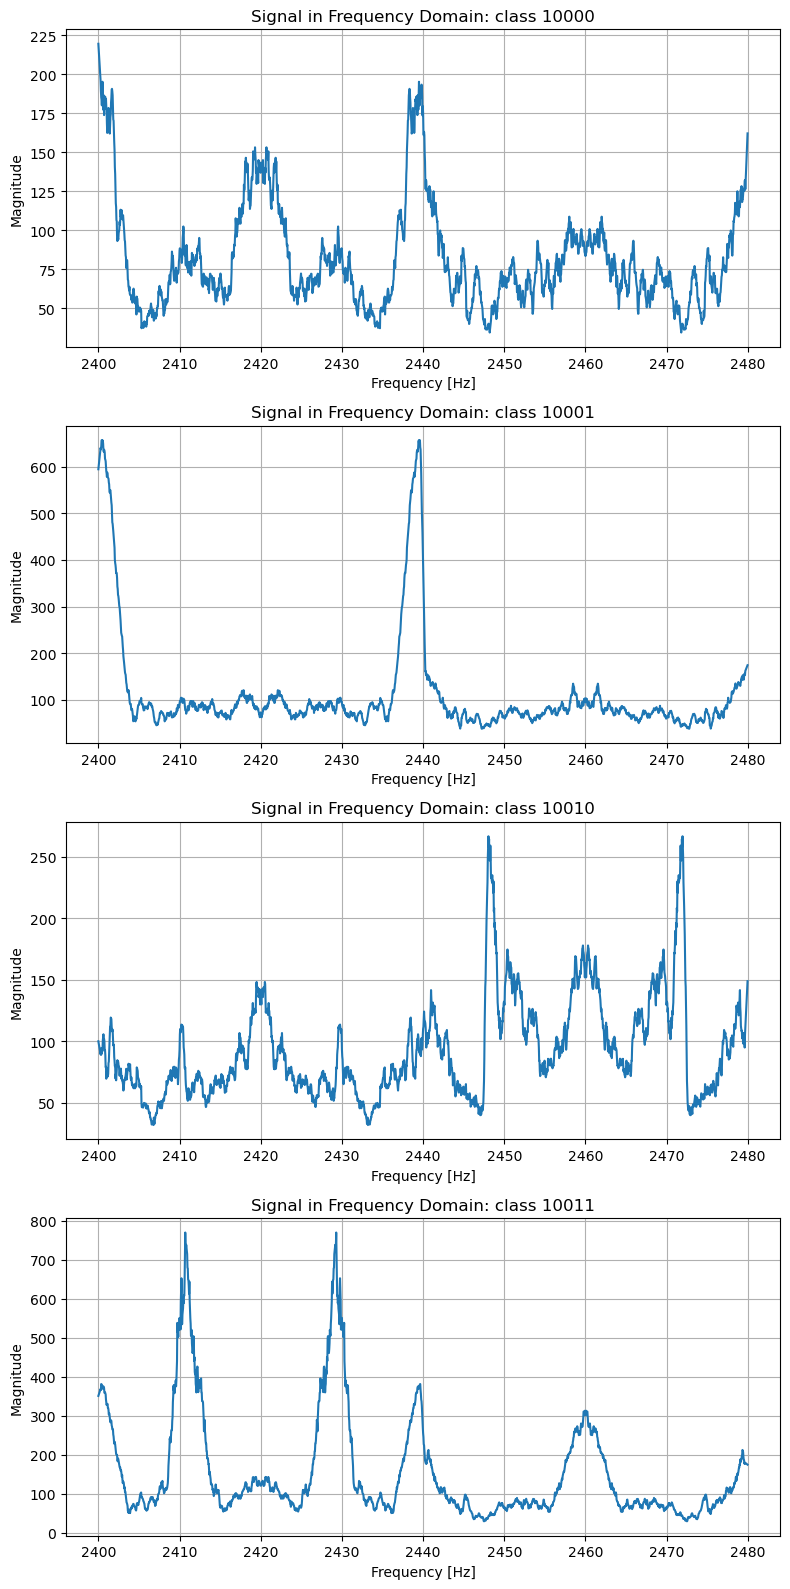

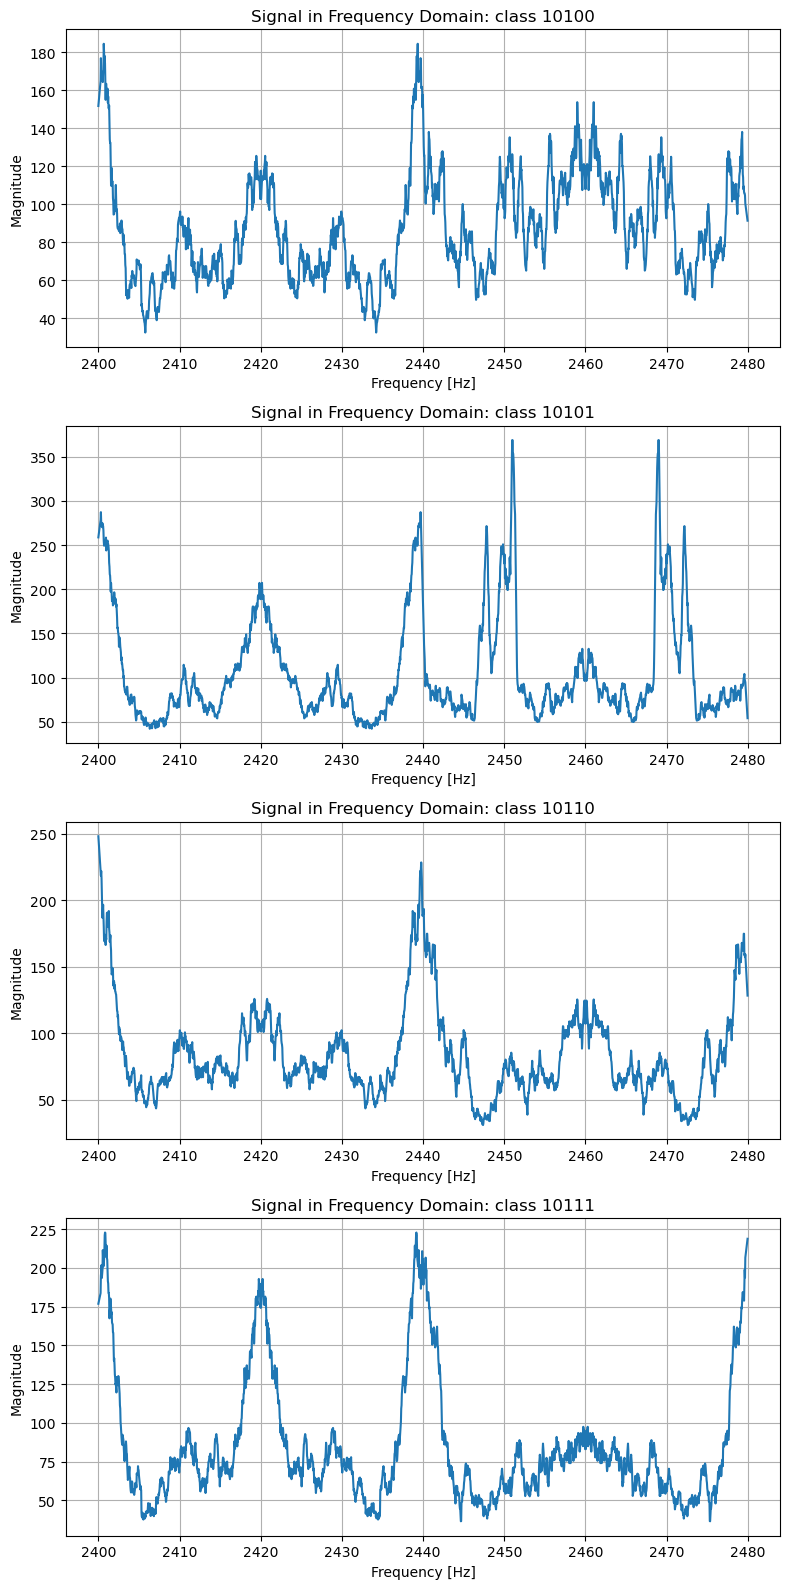

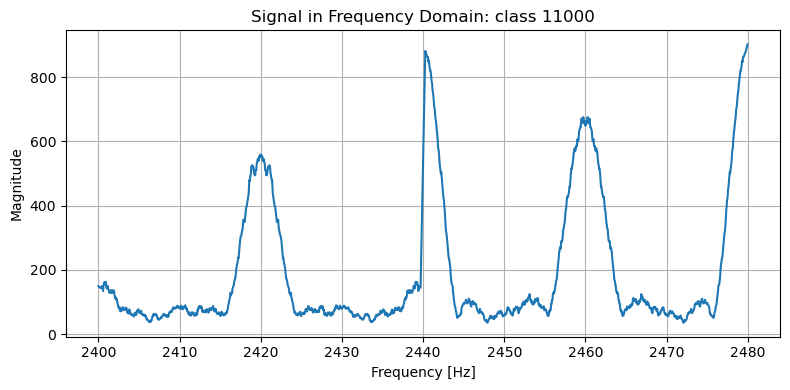

In [4]:
bui_values = list(BUI_dict.values())

for i in range(len(bui_values)):
    fig, ax = plt.subplots(len(bui_values[i]), squeeze=False)
    fig.set_size_inches(8, 4 * len(bui_values[i]))

    for mode in range(len(bui_values[i])):
        
        bui = bui_values[i][mode]
        data = np.loadtxt(os.path.join(save_path, f'{bui}.csv'))

        s = savgol_filter(data, S, 1)

        ax[mode][0].plot(f, s)
        ax[mode][0].set_title(f'Signal in Frequency Domain: class {bui}')
        ax[mode][0].set(xlabel='Frequency [Hz]', ylabel='Magnitude')
        ax[mode][0].grid(True)
    
    fig.tight_layout()
    plt.show()